# Sistema de recomendación con MovieLens 1M
Este notebook implementa y evalúa un modelo de filtrado colaborativo basado en SVD sobre el dataset **MovieLens 1M**. Antes del modelado se realiza una etapa de **entendimiento de los datos**: volúmenes, descripción de atributos, descriptores estadísticos y visualizaciones.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Cargar ratings
ratings = pd.read_csv('ml-1m/ratings.dat', sep='::', engine='python',
                     names=['userId', 'movieId', 'rating', 'timestamp'])

# Cargar películas
movies = pd.read_csv('ml-1m/movies.dat', sep='::', engine='python',
                    names=['movieId', 'title', 'genres'], encoding='latin-1')

# Cargar usuarios
users = pd.read_csv('ml-1m/users.dat', sep='::', engine='python',
                   names=['userId', 'gender', 'age', 'occupation', 'zip'], encoding='latin-1')

ratings.head()


,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


## Entendimiento de los datos

El dataset MovieLens 1M se distribuye en tres tablas relacionadas:
- ratings: valoraciones de usuarios sobre películas (tabla principal del filtrado colaborativo).
- users: datos demográficos de los usuarios.
- movies: catálogo de películas con título y géneros.

A continuación se explora cada tabla en términos de volumen, dominio de los atributos y distribuciones.

In [36]:
# Volumen general del dataset
n_ratings = len(ratings)
n_users = users['userId'].nunique()
n_users_sin_rating = len(set(users['userId']) - set(ratings['userId']))
n_movies_catalog = movies['movieId'].nunique()
n_movies_rated = ratings['movieId'].nunique()
density = n_ratings / (n_users * n_movies_rated)

resumen = pd.DataFrame({
    'Métrica': [
        'n° ratings',
        'n° usuarios',
        'n° usuarios sin rating',
        'n° películas',
        'n° películas con al menos un rating',
        '% celdas vacías de la matriz usuario-pelicula',
    ],
    'Valor': [
        f'{n_ratings:,}',
        f'{n_users:,}',
        f'{n_users_sin_rating:,}',
        f'{n_movies_catalog:,}',
        f'{n_movies_rated:,}',
        f'{(1-density)*100:.4f}%',
    ]
})
resumen


,Métrica,Valor
0,n° ratings,"1,000,209"
1,n° usuarios,"6,040"
2,n° usuarios sin rating,0
3,n° películas,"3,883"
4,n° películas con al menos un rating,"3,706"
5,% celdas vacías de la matriz usuario-pelicula,95.5316%


### Descripción de atributos por tabla
Para cada tabla del dataset se documenta el **nombre**, el **tipo de dato** y el **rango / dominio** de los valores observados. Esta caracterización guía las decisiones posteriores de preprocesamiento y modelado.

In [37]:
# Descripción de atributos: nombre, tipo, rango/dominio y transformación para entendimiento
age_labels = {1:'<18', 18:'18-24', 25:'25-34', 35:'35-44', 45:'45-49', 50:'50-55', 56:'56+'}
occupation_labels = {
    0:'other/n.s.', 1:'academic/educator', 2:'artist', 3:'clerical/admin',
    4:'college/grad student', 5:'customer service', 6:'doctor/health care',
    7:'executive/managerial', 8:'farmer', 9:'homemaker', 10:'K-12 student',
    11:'lawyer', 12:'programmer', 13:'retired', 14:'sales/marketing',
    15:'scientist', 16:'self-employed', 17:'technician/engineer',
    18:'tradesman/craftsman', 19:'unemployed', 20:'writer'
}

generos_distintos = sorted({g for gs in movies['genres'].str.split('|') for g in gs})

atributos = pd.DataFrame([
    # ratings
    ['ratings', 'userId',    'Entero (ID)',          'Discreto', f"{ratings['userId'].min()}..{ratings['userId'].max()}", ''],
    ['ratings', 'movieId',   'Entero (ID)',          'Discreto', f"{ratings['movieId'].min()}..{ratings['movieId'].max()}", ''],
    ['ratings', 'rating',    'Entero (ordinal)',     'Discreto', f"{sorted(ratings['rating'].unique())}", ''],

    # users
    ['users', 'userId',     'Entero (ID)',           'Discreto', f"{users['userId'].min()}..{users['userId'].max()}", ''],
    ['users', 'gender',     'Categórico (binario)',  'Nominal',  f"{sorted(users['gender'].unique())}", ''],
    ['users', 'age',        'Categórico (ordinal)',  'Ordinal',  f"{sorted(users['age'].unique())}",
        f"{list(age_labels.values())}"],
    ['users', 'occupation', 'Categórico (nominal)',  'Nominal',  f"0..20 ({users['occupation'].nunique()} categorías; ej. {occupation_labels[0]}, {occupation_labels[12]})", ''],

    # movies
    ['movies', 'movieId', 'Entero (ID)',          'Discreto', f"{movies['movieId'].min()}..{movies['movieId'].max()}", ''],
    ['movies', 'title',   'Texto libre',          'Nominal',  f"Título IMDB con año entre paréntesis", ''],
    ['movies', 'genres',  'Texto multi-etiqueta', 'Nominal',  f"Cadena de géneros separados por '|'",
        f"{generos_distintos}"],
], columns=['Tabla', 'Atributo', 'Tipo', 'Escala', 'Rango / dominio de valores', 'Transformación para entendimiento'])

pd.set_option('display.max_colwidth', None)
atributos


,Tabla,Atributo,Tipo,Escala,Rango / dominio de valores,Transformación para entendimiento
0,ratings,userId,Entero (ID),Discreto,1..6040,
1,ratings,movieId,Entero (ID),Discreto,1..3952,
2,ratings,rating,Entero (ordinal),Discreto,"[1, 2, 3, 4, 5]",
3,users,userId,Entero (ID),Discreto,1..6040,
4,users,gender,Categórico (binario),Nominal,"['F', 'M']",
5,users,age,Categórico (ordinal),Ordinal,"[1, 18, 25, 35, 45, 50, 56]","['<18', '18-24', '25-34', '35-44', '45-49', '50-55', '56+']"
6,users,occupation,Categórico (nominal),Nominal,"0..20 (21 categorías; ej. other/n.s., programmer)",
7,movies,movieId,Entero (ID),Discreto,1..3952,
8,movies,title,Texto libre,Nominal,Título IMDB con año entre paréntesis,
9,movies,genres,Texto multi-etiqueta,Nominal,Cadena de géneros separados por '|',"['Action', 'Adventure', 'Animation', ""Children's"", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']"


### Descriptores estadísticos
Para cada atributo numérico se reportan medidas de tendencia central (media, mediana y moda) y de dispersión: varianza, rango (mínimo y máximo) y rango intercuartílico (IQR).

In [38]:
# Descriptores estadísticos de los atributos numéricos clave
def descriptores(serie, nombre):
    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode().iloc[0]
    var = serie.var()
    minimo, maximo = serie.min(), serie.max()
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    print(f"{nombre}")
    print(f"  media        : {media:.4f}")
    print(f"  mediana      : {mediana:g}")
    print(f"  moda         : {moda}")
    print(f"  varianza     : {var:.4f}")
    print(f"  rango        : [{minimo:g} .. {maximo:g}]  (amplitud = {maximo-minimo:g})")
    print(f"  IQR (Q1..Q3) : [{q1:g} .. {q3:g}]  (amplitud = {iqr:g})")
    print()

descriptores(ratings['rating'], "rating (1-5)")

ratings_por_usuario = ratings.groupby('userId').size()
descriptores(ratings_por_usuario, "Cantidad de ratings por usuario")

ratings_por_pelicula = ratings.groupby('movieId').size()
descriptores(ratings_por_pelicula, "Cantidad de ratings por película")

# Distribución absoluta y relativa de los ratings
# (relevante porque la media queda por debajo de la moda: distribución sesgada hacia ratings altos)
print("Distribución del rating:")
dist_rating = (
    ratings['rating'].value_counts().sort_index()
    .to_frame('frecuencia')
    .assign(porcentaje=lambda d: (d['frecuencia']/d['frecuencia'].sum()*100).round(2))
)
print(dist_rating.to_string())


rating (1-5)
  media        : 3.5816
  mediana      : 4
  moda         : 4
  varianza     : 1.2479
  rango        : [1 .. 5]  (amplitud = 4)
  IQR (Q1..Q3) : [3 .. 4]  (amplitud = 1)

Cantidad de ratings por usuario
  media        : 165.5975
  mediana      : 96
  moda         : 21
  varianza     : 37151.4172
  rango        : [20 .. 2314]  (amplitud = 2294)
  IQR (Q1..Q3) : [44 .. 208]  (amplitud = 164)

Cantidad de ratings por película
  media        : 269.8891
  mediana      : 123.5
  moda         : 1
  varianza     : 147492.7415
  rango        : [1 .. 3428]  (amplitud = 3427)
  IQR (Q1..Q3) : [33 .. 350]  (amplitud = 317)

Distribución del rating:
        frecuencia  porcentaje
rating                        
1            56174        5.62
2           107557       10.75
3           261197       26.11
4           348971       34.89
5           226310       22.63


### Visualizaciones
Las siguientes visualizaciones ayudan a caracterizar las distribuciones de los atributos y detectar posibles sesgos (por ejemplo, ratings concentrados en valores altos, usuarios con muy pocas valoraciones o películas con baja cobertura).

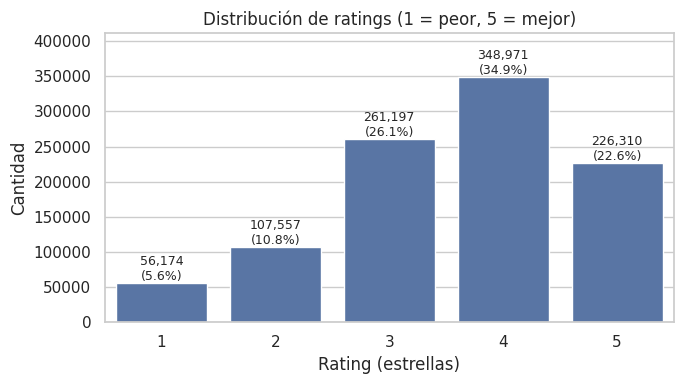

In [39]:
# Distribución de la variable rating
fig, ax = plt.subplots(figsize=(7, 4))
order = [1, 2, 3, 4, 5]
counts = ratings['rating'].value_counts().reindex(order)
sns.barplot(x=order, y=counts.values, ax=ax, color="#4C72B0")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({v/counts.sum()*100:.1f}%)", ha='center', va='bottom', fontsize=9)
ax.set_title("Distribución de ratings (1 = peor, 5 = mejor)")
ax.set_xlabel("Rating (estrellas)")
ax.set_ylabel("Cantidad")
ax.set_ylim(0, counts.max()*1.18)
plt.tight_layout()
plt.show()


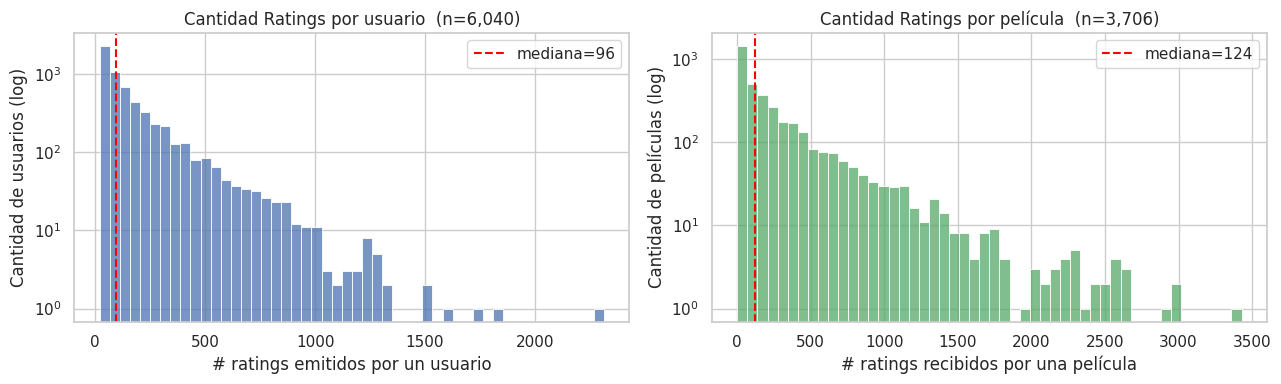

In [40]:
# Distribución de actividad: ratings por usuario y ratings por película (escala log)
ratings_por_usuario = ratings.groupby('userId').size()
ratings_por_pelicula = ratings.groupby('movieId').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(ratings_por_usuario, bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_yscale('log')
axes[0].set_title(f"Cantidad Ratings por usuario  (n={len(ratings_por_usuario):,})")
axes[0].set_xlabel("# ratings emitidos por un usuario")
axes[0].set_ylabel("Cantidad de usuarios (log)")
axes[0].axvline(ratings_por_usuario.median(), color='red', linestyle='--', label=f"mediana={ratings_por_usuario.median():.0f}")
axes[0].legend()

sns.histplot(ratings_por_pelicula, bins=50, ax=axes[1], color="#55A868")
axes[1].set_yscale('log')
axes[1].set_title(f"Cantidad Ratings por película  (n={len(ratings_por_pelicula):,})")
axes[1].set_xlabel("# ratings recibidos por una película")
axes[1].set_ylabel("Cantidad de películas (log)")
axes[1].axvline(ratings_por_pelicula.median(), color='red', linestyle='--', label=f"mediana={ratings_por_pelicula.median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()


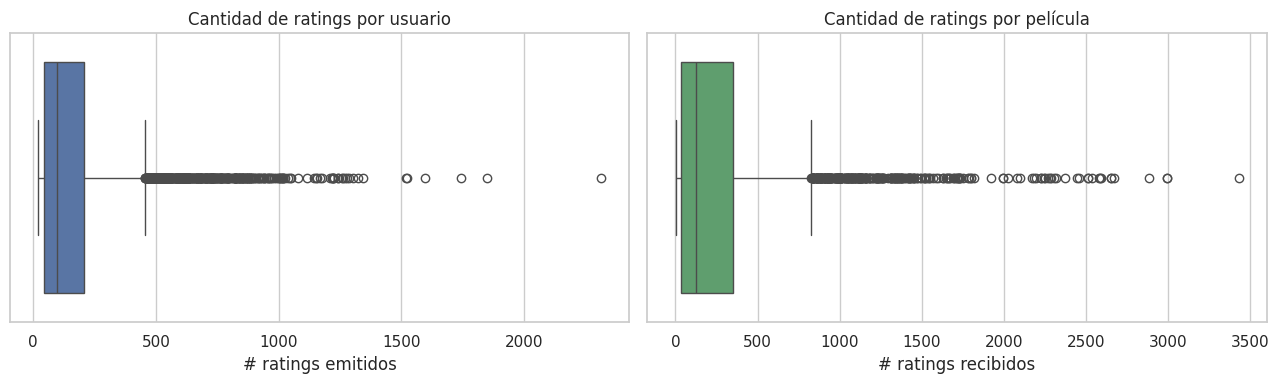

In [41]:
# Boxplot: distribución de cantidad de ratings por usuario y por película
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(x=ratings_por_usuario, ax=axes[0], color="#4C72B0")
axes[0].set_title("Cantidad de ratings por usuario")
axes[0].set_xlabel("# ratings emitidos")

sns.boxplot(x=ratings_por_pelicula, ax=axes[1], color="#55A868")
axes[1].set_title("Cantidad de ratings por película")
axes[1].set_xlabel("# ratings recibidos")

plt.tight_layout()
plt.show()


La edad esta discretizada con etiquetas que representan rangos de edades

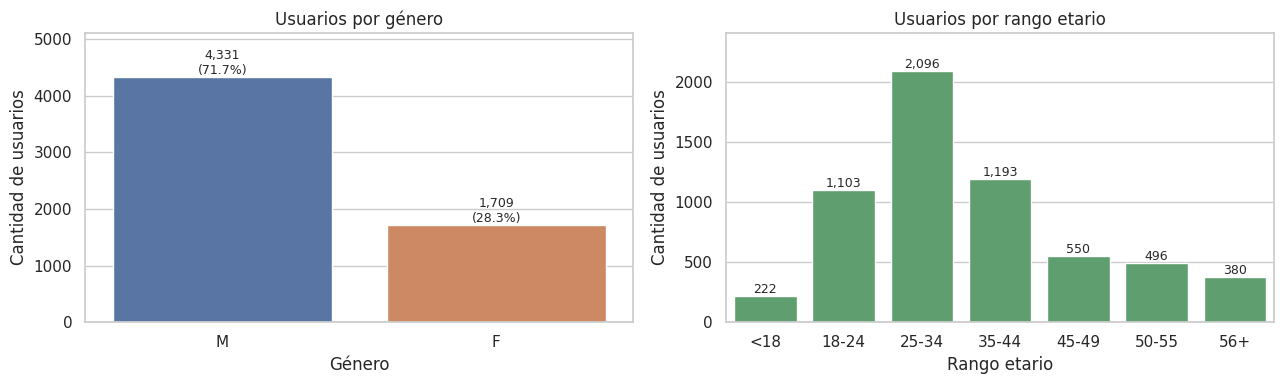

In [42]:
# Distribución demográfica de usuarios: género y rango etario
age_labels = {1:'<18', 18:'18-24', 25:'25-34', 35:'35-44', 45:'45-49', 50:'50-55', 56:'56+'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

gender_counts = users['gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, hue=gender_counts.index, ax=axes[0], palette=["#4C72B0", "#DD8452"], legend=False)
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v, f"{v:,}\n({v/gender_counts.sum()*100:.1f}%)", ha='center', va='bottom', fontsize=9)
axes[0].set_title("Usuarios por género")
axes[0].set_xlabel("Género")
axes[0].set_ylabel("Cantidad de usuarios")
axes[0].set_ylim(0, gender_counts.max()*1.18)

age_counts = users['age'].value_counts().sort_index()
labels = [age_labels[a] for a in age_counts.index]
sns.barplot(x=labels, y=age_counts.values, ax=axes[1], color="#55A868")
for i, v in enumerate(age_counts.values):
    axes[1].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=9)
axes[1].set_title("Usuarios por rango etario")
axes[1].set_xlabel("Rango etario")
axes[1].set_ylabel("Cantidad de usuarios")
axes[1].set_ylim(0, age_counts.max()*1.15)

plt.tight_layout()
plt.show()


Para visualizar la frecuencia de los géneros fue necesario realizar una transformación, ya que el valor contenía varios géneros separados por |

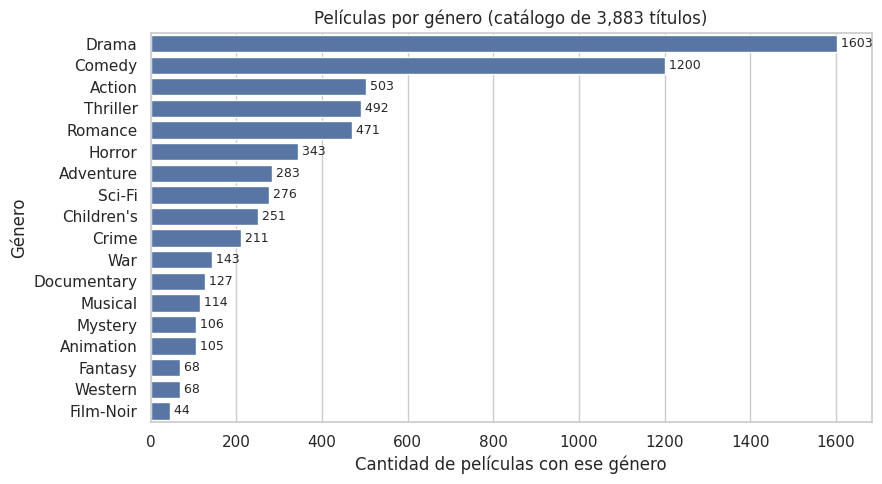

In [43]:
# Géneros de películas (una película puede tener varios géneros)
generos_explode = movies['genres'].str.split('|').explode()
gen_counts = generos_explode.value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=gen_counts.values, y=gen_counts.index, ax=ax, color="#4C72B0")
for i, v in enumerate(gen_counts.values):
    ax.text(v, i, f" {v}", va='center', fontsize=9)
ax.set_title(f"Películas por género (catálogo de {len(movies):,} títulos)")
ax.set_xlabel("Cantidad de películas con ese género")
ax.set_ylabel("Género")
plt.tight_layout()
plt.show()


### Calidad de los datos
Antes de modelar, se revisan los chequeos elementales de calidad: ausencia de valores nulos, filas duplicadas y unicidad de claves primarias.

In [44]:
# Calidad básica de los datos: valores nulos, duplicados, unicidad de claves
# e integridad referencial entre tablas
print("Valores nulos por tabla y atributo:")
for nombre, df in [('ratings', ratings), ('users', users), ('movies', movies)]:
    nulos = df.isna().sum()
    detalle = ", ".join(f"{c}={n}" for c, n in nulos.items())
    print(f"  {nombre:8s}: {detalle}")

print("\nFilas duplicadas:")
print(f"  ratings : {ratings.duplicated().sum()}")
print(f"  users   : {users.duplicated().sum()}")
print(f"  movies  : {movies.duplicated().sum()}")

print("\nClaves duplicadas:")
print(f"  ratings (userId, movieId): {ratings.duplicated(subset=['userId','movieId']).sum()}")
print(f"  users  (userId)          : {users.duplicated(subset=['userId']).sum()}")
print(f"  movies (movieId)         : {movies.duplicated(subset=['movieId']).sum()}")

# Cobertura e integridad referencial entre tablas
usuarios_sin_rating = set(users['userId']) - set(ratings['userId'])
peliculas_sin_rating = set(movies['movieId']) - set(ratings['movieId'])
ratings_user_huerfano = set(ratings['userId']) - set(users['userId'])
ratings_movie_huerfano = set(ratings['movieId']) - set(movies['movieId'])

print("\nCobertura:")
print(f"  usuarios sin ningún rating               : {len(usuarios_sin_rating):>4} de {len(users):>4} ({len(usuarios_sin_rating)/len(users)*100:.2f}%)")
print(f"  películas sin ningún rating (cold-start) : {len(peliculas_sin_rating):>4} de {len(movies):>4} ({len(peliculas_sin_rating)/len(movies)*100:.2f}%)")
print(f"  ratings con userId que no está en users  : {len(ratings_user_huerfano)}")
print(f"  ratings con movieId que no está en movies: {len(ratings_movie_huerfano)}")


Valores nulos por tabla y atributo:
  ratings : userId=0, movieId=0, rating=0, timestamp=0
  users   : userId=0, gender=0, age=0, occupation=0, zip=0
  movies  : movieId=0, title=0, genres=0

Filas duplicadas:
  ratings : 0
  users   : 0
  movies  : 0

Claves duplicadas:
  ratings (userId, movieId): 0
  users  (userId)          : 0
  movies (movieId)         : 0

Cobertura:
  usuarios sin ningún rating               :    0 de 6040 (0.00%)
  películas sin ningún rating (cold-start) :  177 de 3883 (4.56%)
  ratings con userId que no está en users  : 0
  ratings con movieId que no está en movies: 0


#### Limpieza
No es necesario limpiar el dataset. 

Las películas sin ratings se conservan porque forman parte del catálogo original y permiten medir la cobertura del dataset. No participan en el SVD, ya que la matriz usuario-película se construye desde ratings, por lo que quedan excluidas automáticamente. Representan cold-start de ítem, en esta notebook trabajamos sobre el filtrado colaborativo unicamente, pero podrían mitigarse con estrategias basadas en contenido.

#### Sesgos
Detectamos los siguientes sesgos en el dataset respecto a rating, usuarios y peliculas:

**Sesgo de popularidad:** algunas películas tienen muchísimos ratings y muchas tienen pocos.

**Sesgo de actividad:** algunos usuarios califican muchísimas películas y otros pocas.

**Sesgo de calificación:** los ratings altos, especialmente 4 y 5, aparecen con más frecuencia que los bajos.

En base a los sesgmos podemos decir que no todos los ratings aportan la misma cantidad de información al modelo. Un rating sobre una película muy popular puede ayudar más a encontrar usuarios similares, porque existen muchas otras calificaciones sobre esa misma película. En cambio, un rating sobre una película poco calificada aporta menos puntos de comparación.

#### Conclusión de calidad
Precisión: los ratings respetan la escala 1-5 y no se detectan duplicados usuario-película ni errores evidentes.

Completitud: no hay nulos explícitos en las tablas originales, aunque existen películas sin ratings que representan cold-start de ítem.

Credibilidad: los valores extremos de usuarios muy activos y películas muy populares son creíbles y se conservan como patrones reales del sistema.

Interpretabilidad: algunos atributos codificados, como edad y ocupación, requieren etiquetas descriptivas para comprender su significado.

## Modelo SVD Tradicional

In [45]:
# validación Split Data
from sklearn.model_selection import KFold
from scipy.sparse.linalg import svds
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

cv_folds = 5
kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
rmse_scores = []
mae_scores = []

for train_idx, test_idx in kf.split(ratings):
    train_ratings = ratings.iloc[train_idx]
    test_ratings = ratings.iloc[test_idx]
    
    # Crear matriz usuario-película
    train_matrix = train_ratings.pivot(index='userId', columns='movieId', values='rating')
    
    # CLAVE: Calcular medias SOLO sobre valores reales (ignorando NaN)
    user_means = train_matrix.mean(axis=1).fillna(0)
    
    # Normalizar ANTES de rellenar
    matrix_norm = train_matrix.sub(user_means, axis=0)
    
    # AHORA sí rellenar con 0 (representa "desviación desconocida")
    matrix_norm_filled = matrix_norm.fillna(0).values
    
    # SVD
    U, sigma, Vt = svds(matrix_norm_filled, k=100)
    sigma = np.diag(sigma)
    
    # Reconstruir y desnormalizar
    all_predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_means.values.reshape(-1, 1)
    
    # Limitar predicciones al rango válido
    all_predicted_ratings = np.clip(all_predicted_ratings, 1, 5)
    
    preds_train_df = pd.DataFrame(
        all_predicted_ratings, 
        columns=train_matrix.columns, 
        index=train_matrix.index
    )
    
    # Evaluar en test
    test_filtered = test_ratings[
        test_ratings['movieId'].isin(preds_train_df.columns) & 
        test_ratings['userId'].isin(preds_train_df.index)
    ]
    
    preds = []
    for _, row in test_filtered.iterrows():
        user = row['userId']
        movie = row['movieId']
        pred = preds_train_df.loc[user, movie]
        preds.append(pred)
    
    if len(preds) > 0:
        rmse = np.sqrt(mean_squared_error(test_filtered['rating'], preds))
        mae = mean_absolute_error(test_filtered['rating'], preds)
        rmse_scores.append(rmse)
        mae_scores.append(mae)

print(f'RMSE promedio: {np.mean(rmse_scores):.4f}')
print(f'MAE promedio: {np.mean(mae_scores):.4f}')

RMSE promedio: 0.9755
MAE promedio: 0.7733


In [46]:
# ========== MÉTRICAS ADICIONALES PARA SVD MANUAL ==========
from collections import defaultdict
import numpy as np
import random

# Configuración
k_top = 10
threshold = 3

# Volver a ejecutar UN FOLD para obtener predicciones
# (usamos el último fold del cross-validation anterior)
train_ratings = ratings.iloc[train_idx]
test_ratings = ratings.iloc[test_idx]

# Crear matriz usuario-película
train_matrix = train_ratings.pivot(index='userId', columns='movieId', values='rating')
user_means = train_matrix.mean(axis=1).fillna(0)
matrix_norm = train_matrix.sub(user_means, axis=0)
matrix_norm_filled = matrix_norm.fillna(0).values

# SVD
U, sigma, Vt = svds(matrix_norm_filled, k=20)
sigma = np.diag(sigma)

# Reconstruir
all_predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_means.values.reshape(-1, 1)
all_predicted_ratings = np.clip(all_predicted_ratings, 1, 5)

preds_train_df = pd.DataFrame(
    all_predicted_ratings, 
    columns=train_matrix.columns, 
    index=train_matrix.index
)

# Filtrar test
test_filtered = test_ratings[
    test_ratings['movieId'].isin(preds_train_df.columns) & 
    test_ratings['userId'].isin(preds_train_df.index)
]


# ========== FUNCIONES DE EVALUACIÓN ==========
def precision_recall_at_k_manual(test_filtered, preds_df, k=10, threshold=3.5):
    """Calcula Precision@K y Recall@K para SVD manual"""
    
    # Agrupar por usuario
    user_predictions = defaultdict(list)
    
    for _, row in test_filtered.iterrows():
        user = row['userId']
        movie = row['movieId']
        true_rating = row['rating']
        pred_rating = preds_df.loc[user, movie]
        
        user_predictions[user].append((pred_rating, true_rating))
    
    precisions = []
    recalls = []
    
    for user, predictions in user_predictions.items():
        # Ordenar por predicción descendente
        predictions_sorted = sorted(predictions, key=lambda x: x[0], reverse=True)
        
        # Top-k
        top_k = predictions_sorted[:k]
        
        # Relevantes en top-k
        n_rel_and_rec_k = sum(1 for (_, true_r) in top_k if true_r >= threshold)
        
        # Total relevantes
        n_rel = sum(1 for (_, true_r) in predictions if true_r >= threshold)
        
        # Precision y Recall
        if k > 0:
            precisions.append(n_rel_and_rec_k / k)
        if n_rel > 0:
            recalls.append(n_rel_and_rec_k / n_rel)
    
    return np.mean(precisions) if precisions else 0, np.mean(recalls) if recalls else 0


def coverage_manual(test_filtered, preds_df, train_matrix, threshold=3.5):
    """Calcula coverage para SVD manual"""
    
    # Todas las películas en el dataset de entrenamiento
    all_movies = set(train_matrix.columns)
    
    # Películas recomendadas (con predicción >= threshold)
    recommended_movies = set()
    
    for _, row in test_filtered.iterrows():
        user = row['userId']
        movie = row['movieId']
        pred_rating = preds_df.loc[user, movie]
        
        if pred_rating >= threshold:
            recommended_movies.add(movie)
    
    coverage_score = len(recommended_movies) / len(all_movies) if len(all_movies) > 0 else 0
    return coverage_score


# ========== CALCULAR MÉTRICAS ==========
print("=" * 60)
print("SVD MANUAL - MÉTRICAS ADICIONALES")
print("=" * 60)

precision, recall = precision_recall_at_k_manual(test_filtered, preds_train_df, k=k_top, threshold=threshold)
cov = coverage_manual(test_filtered, preds_train_df, train_matrix, threshold=threshold)

print(f"Precision@{k_top}: {precision:.4f}")
print(f"Recall@{k_top}:    {recall:.4f}")
print(f"Coverage:     {cov:.4f} ({cov*100:.2f}% del catálogo)")

if precision + recall > 0:
    f1 = 2 * (precision * recall) / (precision + recall)
    print(f"F1-Score:     {f1:.4f}")


# ========== EJEMPLOS: PREDICCIONES VS REALES ==========
print("\n" + "=" * 60)
print("EJEMPLOS: PREDICCIONES VS RATINGS REALES")
print("=" * 60)
print(f"{'Usuario':<10} {'Película':<10} {'Real':<8} {'Predicho':<10} {'Error':<8}")
print("-" * 60)

# Seleccionar muestra aleatoria
sample_size = min(20, len(test_filtered))
sample_indices = random.sample(range(len(test_filtered)), sample_size)

for idx in sample_indices:
    row = test_filtered.iloc[idx]
    user = row['userId']
    movie = row['movieId']
    true_rating = row['rating']
    pred_rating = preds_train_df.loc[user, movie]
    error = abs(true_rating - pred_rating)
    
    print(f"{user:<10} {movie:<10} {true_rating:<8.1f} {pred_rating:<10.2f} {error:<8.2f}")


# ========== DISTRIBUCIÓN DE ERRORES ==========
print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE ERRORES")
print("=" * 60)

# Calcular todos los errores
errors = []
for _, row in test_filtered.iterrows():
    user = row['userId']
    movie = row['movieId']
    true_rating = row['rating']
    pred_rating = preds_train_df.loc[user, movie]
    error = abs(true_rating - pred_rating)
    errors.append(error)

print(f"Error promedio:      {np.mean(errors):.4f}")
print(f"Error mediano:       {np.median(errors):.4f}")
print(f"Error máximo:        {np.max(errors):.4f}")
print(f"Desviación estándar: {np.std(errors):.4f}")

print("\nDistribución de errores absolutos:")
bins = [0, 0.5, 1.0, 1.5, 2.0, 5.0]
for i in range(len(bins)-1):
    count = sum(1 for e in errors if bins[i] <= e < bins[i+1])
    percentage = (count / len(errors)) * 100
    print(f"  {bins[i]:.1f} - {bins[i+1]:.1f}: {count:6d} ({percentage:5.2f}%)")


# ========== ANÁLISIS POR USUARIO ==========
print("\n" + "=" * 60)
print("TOP 5 USUARIOS CON MEJOR/PEOR PREDICCIÓN")
print("=" * 60)

# Calcular error promedio por usuario
user_errors = defaultdict(list)
for _, row in test_filtered.iterrows():
    user = row['userId']
    movie = row['movieId']
    true_rating = row['rating']
    pred_rating = preds_train_df.loc[user, movie]
    error = abs(true_rating - pred_rating)
    user_errors[user].append(error)

# Promediar errores por usuario
user_avg_errors = {user: np.mean(errors) for user, errors in user_errors.items() if len(errors) >= 5}

if user_avg_errors:
    # Mejores usuarios (menor error)
    best_users = sorted(user_avg_errors.items(), key=lambda x: x[1])[:5]
    print("\nMejor predicción (menor error):")
    for user, avg_error in best_users:
        n_ratings = len(user_errors[user])
        print(f"  Usuario {user}: Error promedio = {avg_error:.4f} ({n_ratings} ratings)")
    
    # Peores usuarios (mayor error)
    worst_users = sorted(user_avg_errors.items(), key=lambda x: x[1], reverse=True)[:5]
    print("\nPeor predicción (mayor error):")
    for user, avg_error in worst_users:
        n_ratings = len(user_errors[user])
        print(f"  Usuario {user}: Error promedio = {avg_error:.4f} ({n_ratings} ratings)")

SVD MANUAL - MÉTRICAS ADICIONALES
Precision@10: 0.8250
Recall@10:    0.5968
Coverage:     0.9244 (92.44% del catálogo)
F1-Score:     0.6926

EJEMPLOS: PREDICCIONES VS RATINGS REALES
Usuario    Película   Real     Predicho   Error   
------------------------------------------------------------
5519       1091       2.0      3.15       1.15    
1389       3491       5.0      3.84       1.16    
1794       1268       2.0      2.46       0.46    
2071       2836       5.0      3.37       1.63    
4054       104        4.0      3.76       0.24    
3327       1799       4.0      3.54       0.46    
5186       1375       3.0      3.53       0.53    
1943       911        5.0      3.83       1.17    
2590       3173       4.0      3.07       0.93    
1053       2433       3.0      3.16       0.16    
744        1288       1.0      3.85       2.85    
5876       2313       4.0      3.72       0.28    
3224       62         4.0      3.82       0.18    
182        514        3.0      3.92       0

In [47]:
# --- Validación Cruzada K-Fold ---
from sklearn.model_selection import KFold
from scipy.sparse.linalg import svds
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configurar K-Fold
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Almacenar métricas de cada fold
rmse_scores = []
mae_scores = []

print(f"Ejecutando validación cruzada con {n_splits} folds...\n")

# Iterar sobre los folds
for fold, (train_idx, test_idx) in enumerate(kf.split(ratings), 1):
    print(f"Fold {fold}/{n_splits}")
    
    # Dividir datos
    train_ratings = ratings.iloc[train_idx]
    test_ratings = ratings.iloc[test_idx]
    
    # Crear matriz usuario-película
    train_matrix = train_ratings.pivot(index='userId', columns='movieId', values='rating')
    
    # Calcular medias SOLO sobre valores reales (ignorando NaN)
    user_means = train_matrix.mean(axis=1).fillna(0)
    
    # Normalizar ANTES de rellenar
    matrix_norm = train_matrix.sub(user_means, axis=0)
    
    # Rellenar con 0 (desviación desconocida)
    matrix_norm_filled = matrix_norm.fillna(0).values
    
    # SVD
    U, sigma, Vt = svds(matrix_norm_filled, k=100)
    sigma = np.diag(sigma)
    
    # Reconstruir y desnormalizar
    all_predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_means.values.reshape(-1, 1)
    
    # Limitar predicciones al rango válido
    all_predicted_ratings = np.clip(all_predicted_ratings, 1, 5)
    
    preds_train_df = pd.DataFrame(
        all_predicted_ratings, 
        columns=train_matrix.columns, 
        index=train_matrix.index
    )
    
    # Evaluar en test
    test_filtered = test_ratings[
        test_ratings['movieId'].isin(preds_train_df.columns) & 
        test_ratings['userId'].isin(preds_train_df.index)
    ]
    
    preds = []
    for _, row in test_filtered.iterrows():
        user = row['userId']
        movie = row['movieId']
        pred = preds_train_df.loc[user, movie]
        preds.append(pred)
    
    if len(preds) > 0:
        rmse = np.sqrt(mean_squared_error(test_filtered['rating'], preds))
        mae = mean_absolute_error(test_filtered['rating'], preds)
        
        rmse_scores.append(rmse)
        mae_scores.append(mae)
        
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE: {mae:.4f}\n")

# Resultados finales
print("="*50)
print("RESULTADOS DE VALIDACIÓN CRUZADA")
print("="*50)
print(f"RMSE promedio: {np.mean(rmse_scores):.4f} (± {np.std(rmse_scores):.4f})")
print(f"MAE promedio:  {np.mean(mae_scores):.4f} (± {np.std(mae_scores):.4f})")
print("\nRMSE por fold:", [f"{score:.4f}" for score in rmse_scores])
print("MAE por fold: ", [f"{score:.4f}" for score in mae_scores])

Ejecutando validación cruzada con 5 folds...

Fold 1/5
  RMSE: 0.9795
  MAE: 0.7770

Fold 2/5
  RMSE: 0.9728
  MAE: 0.7713

Fold 3/5
  RMSE: 0.9738
  MAE: 0.7719

Fold 4/5
  RMSE: 0.9761
  MAE: 0.7733

Fold 5/5
  RMSE: 0.9752
  MAE: 0.7731

RESULTADOS DE VALIDACIÓN CRUZADA
RMSE promedio: 0.9755 (± 0.0023)
MAE promedio:  0.7733 (± 0.0020)

RMSE por fold: ['0.9795', '0.9728', '0.9738', '0.9761', '0.9752']
MAE por fold:  ['0.7770', '0.7713', '0.7719', '0.7733', '0.7731']


## Modelo Surprise SVD

## Optimización de Hiperparámetros (GridSearchCV)
Para encontrar de forma científica la combinación de parámetros más conveniente para el modelo, implementamos un proceso de búsqueda exhaustiva en cuadrícula mediante la clase GridSearchCV de la librería Surprise. 

El algoritmo evaluará el producto cartesiano de las siguientes opciones configuradas en el espacio de búsqueda:
* n_factors (Factores latentes): `[20, 50, 100]`
* lr_all (Tasa de aprendizaje): `[0.002, 0.005, 0.01]`
* reg_all (Término de regularización): `[0.02, 0.05, 0.1]`

In [48]:
# ========== OPTIMIZACIÓN CON SURPRISE GRIDSEARCHCV ==========
from surprise import SVD, Dataset, Reader
from surprise.model_selection import GridSearchCV

# 1. Crear el dataset para Surprise
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# 2. Definimos la cuadrícula con las opciones que queremos que la computadora pruebe
param_grid = {
    'n_factors': [20, 50, 100],
    'lr_all': [0.002, 0.005, 0.01],
    'reg_all': [0.02, 0.05, 0.1]
}

print("Iniciando búsqueda automática de los mejores parámetros...")
# 3. Configuramos la búsqueda (probará las 27 combinaciones usando 5 pliegues cada una)
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=5, n_jobs=-1)

# 4. Ejecutamos el entrenamiento masivo
gs.fit(data)

# 5. Imprimimos los resultados ganadores
print("=" * 50)
print(f"Mejor RMSE encontrado: {gs.best_score['rmse']:.4f}")
print(f"Mejores parámetros asignados: {gs.best_params['rmse']}")
print("=" * 50)

# A partir de acá, usás estos parámetros ganadores para entrenar tu modelo final
best_n_factors = gs.best_params['rmse']['n_factors']
best_lr_all = gs.best_params['rmse']['lr_all']
best_reg_all = gs.best_params['rmse']['reg_all']

Iniciando búsqueda automática de los mejores parámetros...
Mejor RMSE encontrado: 0.8549
Mejores parámetros asignados: {'n_factors': 100, 'lr_all': 0.01, 'reg_all': 0.05}


In [49]:
# ========== VALIDACIÓN CON SURPRISE SVD ==========
from surprise import SVD, Dataset, Reader
from surprise.model_selection import cross_validate
import numpy as np

# Hiperparámetros configurables
n_factors = 100         # Número de factores latentes
n_epochs = 20          # Número de épocas de entrenamiento
lr_all = 0.01        # Tasa de aprendizaje (learning rate)
reg_all = 0.05         # Parámetro de regularización
cv_folds = 5           # Cantidad de folds para validación cruzada

# Crear dataset para Surprise
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# Configurar modelo SVD con gradient descent y regularización
algo = SVD(n_factors=n_factors, n_epochs=n_epochs, lr_all=lr_all, reg_all=reg_all)

# Validación cruzada
print("=" * 60)
print("SURPRISE SVD - VALIDACIÓN CRUZADA (5-Folds)")
print("=" * 60)
results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=cv_folds, verbose=True)

# Resultados finales
print("\n" + "=" * 60)
print("RESULTADOS FINALES")
print("=" * 60)
print(f'RMSE promedio: {np.mean(results["test_rmse"]):.4f} (± {np.std(results["test_rmse"]):.4f})')
print(f'MAE promedio:  {np.mean(results["test_mae"]):.4f} (± {np.std(results["test_mae"]):.4f})')

SURPRISE SVD - VALIDACIÓN CRUZADA (5-Folds)
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8568  0.8577  0.8533  0.8548  0.8524  0.8550  0.0020  
MAE (testset)     0.6752  0.6750  0.6725  0.6742  0.6713  0.6736  0.0015  
Fit time          9.08    9.21    9.56    9.26    9.36    9.29    0.16    
Test time         1.15    1.48    1.13    1.52    1.16    1.29    0.17    

RESULTADOS FINALES
RMSE promedio: 0.8550 (± 0.0020)
MAE promedio:  0.6736 (± 0.0015)


### Evaluación de Surprise SVD con split 80/20

In [50]:
# ========== EVALUACIÓN SURPRISE SVD - SPLIT 80/20 ==========
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split

# Hiperparámetros (usar los mismos definidos anteriormente)
# n_factors, n_epochs, lr_all, reg_all

# Crear dataset para Surprise
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# Split 80/20
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Entrenar modelo SVD
algo = SVD(n_factors=n_factors, n_epochs=n_epochs, lr_all=lr_all, reg_all=reg_all)
algo.fit(trainset)

# Predecir en test set
predictions = algo.test(testset)

# Calcular métricas
print("=" * 60)
print("SURPRISE SVD - SPLIT TEST (80/20)")
print("=" * 60)
rmse = accuracy.rmse(predictions, verbose=True)
mae = accuracy.mae(predictions, verbose=True)

SURPRISE SVD - SPLIT TEST (80/20)
RMSE: 0.8546
MAE:  0.6728


In [51]:
# ========== EVALUACIÓN SURPRISE (comparable con SVD Manual) ==========
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from db import get_ratings_data
from collections import defaultdict
import numpy as np
import random

# Configuración
k_top = 10
threshold = 3.5

# Datos
ratings = get_ratings_data()
reader = Reader(rating_scale=(ratings['rating'].min(), ratings['rating'].max()))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# Split
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
model = SVD(n_factors=20, n_epochs=20, reg_all=0.1, random_state=42)
model.fit(trainset)

# Predecir directamente sobre el testset → true_r son los ratings reales
predictions = model.test(testset)
print(f"Predicciones sobre testset: {len(predictions)}")


# ========== FUNCIONES ==========
def precision_recall_at_k(predictions, k=10, threshold=3.5):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = [], []
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        k_efectivo = min(k, len(user_ratings))
        top_k = user_ratings[:k_efectivo]
        n_rel_and_rec_k = sum(true_r >= threshold for (_, true_r) in top_k)
        n_rel = sum(true_r >= threshold for (_, true_r) in user_ratings)
        precisions.append(n_rel_and_rec_k / k_efectivo if k_efectivo else 0)
        if n_rel > 0:
            recalls.append(n_rel_and_rec_k / n_rel)

    return np.mean(precisions) if precisions else 0, np.mean(recalls) if recalls else 0


def coverage(predictions, trainset, threshold=3.5):
    all_items = set(trainset.all_items())
    recommended = {iid for _, iid, _, est, _ in predictions if est >= threshold}
    return len(recommended) / len(all_items) if all_items else 0


# ========== MÉTRICAS ==========
print("\n" + "=" * 60)
print("SURPRISE SVD - MÉTRICAS (evaluado sobre testset)")
print("=" * 60)

precision, recall = precision_recall_at_k(predictions, k=k_top, threshold=threshold)
cov = coverage(predictions, trainset, threshold=threshold)

print(f"Precision@{k_top}: {precision:.4f}")
print(f"Recall@{k_top}:    {recall:.4f}")
print(f"Coverage:     {cov:.4f} ({cov*100:.2f}% del catálogo)")
if precision + recall > 0:
    f1 = 2 * (precision * recall) / (precision + recall)
    print(f"F1-Score:     {f1:.4f}")


# ========== EJEMPLOS ==========
print("\n" + "=" * 60)
print("EJEMPLOS: PREDICCIONES VS RATINGS REALES")
print("=" * 60)
print(f"{'Usuario':<10} {'Juego':<10} {'Real':<8} {'Predicho':<10} {'Error':<8}")
print("-" * 60)
for uid, iid, true_r, est, _ in random.sample(predictions, min(20, len(predictions))):
    print(f"{uid:<10} {iid:<10} {true_r:<8.1f} {est:<10.2f} {abs(true_r-est):<8.2f}")


# ========== DISTRIBUCIÓN DE ERRORES ==========
print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE ERRORES")
print("=" * 60)
errors = [abs(true_r - est) for (_, _, true_r, est, _) in predictions]
print(f"Error promedio:      {np.mean(errors):.4f}")
print(f"Error mediano:       {np.median(errors):.4f}")
print(f"Error máximo:        {np.max(errors):.4f}")
print(f"Desviación estándar: {np.std(errors):.4f}")
print("\nDistribución de errores absolutos:")
bins = [0, 0.5, 1.0, 1.5, 2.0, 5.0]
for i in range(len(bins)-1):
    count = sum(bins[i] <= e < bins[i+1] for e in errors)
    print(f"  {bins[i]:.1f} - {bins[i+1]:.1f}: {count:6d} ({count/len(errors)*100:5.2f}%)")


# ========== ANÁLISIS POR USUARIO ==========
print("\n" + "=" * 60)
print("TOP 5 USUARIOS CON MEJOR/PEOR PREDICCIÓN")
print("=" * 60)
user_errors = defaultdict(list)
for uid, iid, true_r, est, _ in predictions:
    user_errors[uid].append(abs(true_r - est))

user_avg_errors = {u: np.mean(e) for u, e in user_errors.items() if len(e) >= 2}
if user_avg_errors:
    print("\nMejor predicción (menor error):")
    for u, e in sorted(user_avg_errors.items(), key=lambda x: x[1])[:5]:
        print(f"  Usuario {u}: Error promedio = {e:.4f} ({len(user_errors[u])} ratings)")
    print("\nPeor predicción (mayor error):")
    for u, e in sorted(user_avg_errors.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  Usuario {u}: Error promedio = {e:.4f} ({len(user_errors[u])} ratings)")

Predicciones sobre testset: 236444

SURPRISE SVD - MÉTRICAS (evaluado sobre testset)
Precision@10: 0.6560
Recall@10:    0.9239
Coverage:     1.0000 (100.00% del catálogo)
F1-Score:     0.7672

EJEMPLOS: PREDICCIONES VS RATINGS REALES
Usuario    Juego      Real     Predicho   Error   
------------------------------------------------------------
117009     62         4.0      3.80       0.20    
120387     63         2.0      2.70       0.70    
122719     57         5.0      4.19       0.81    
113545     62         4.0      3.90       0.10    
123233     59         4.0      4.06       0.06    
114898     19         2.0      3.96       1.96    
124784     90         5.0      3.73       1.27    
3141       96         1.0      2.63       1.63    
115718     65         2.0      3.14       1.14    
120771     61         4.0      4.04       0.04    
4649       55         1.0      2.96       1.96    
4413       81         4.0      4.25       0.25    
118842     22         4.0      2.68       

In [52]:
# Exportar modelo Surprise SVD entrenado (después de fit/trainset)
import pickle
with open('svd_surprise.pkl', 'wb') as f:
    pickle.dump(algo, f)
print('Modelo Surprise SVD guardado en svd_surprise.pkl')

Modelo Surprise SVD guardado en svd_surprise.pkl
